# YouTube Trending Analysis

A beginner-level **EDA / visualization** project exploring engagement on trending YouTube videos, 
200,000 daily stat snapshots of ~11,000 trending videos (views, likes, dislikes, comments over time).


# 01. Setup & Data Loading
First, we will import the necessary libraries for data manipulation and visualization. We are using `pandas` and `numpy` for data wrangling, and `matplotlib` alongside `seaborn` for our charts.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for Seaborn charts
sns.set_theme(style="whitegrid", palette="muted")

## Loading the Dataset
We will load our dataset of 200,000 YouTube trending snapshots and take an initial look at the structure, data types, and any missing values.

In [11]:
# Load the data (update the path if your csv is in a different folder)
df = pd.read_csv('data/youtube.csv')

# Display the first 5 rows
display(df.head())

# Check data types and look for missing values
print("\n--- Dataset Info ---")
df.info()

# Basic summary statistics for numerical columns
display(df.describe())

,videostatsid,ytvideoid,views,comments,likes,dislikes,timestamp
0,1521476,BccyzhMWVmg,4271393,10699,247354,8581,2020-04-10 20:00:05
1,1141953,3bJFIMcr7NI,777256,2439,33858,371,2020-01-21 04:30:16
2,1203248,pX1puTIogCw,1291478,3509,72360,1315,2020-02-03 05:00:39
3,568283,I82TidwcAYM,174606,269,1802,114,2019-08-03 05:32:48
4,501384,_U2nbcAmgOo,189998,583,8898,161,2019-07-20 04:00:23



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   videostatsid  200000 non-null  int64
 1   ytvideoid     200000 non-null  str  
 2   views         200000 non-null  int64
 3   comments      200000 non-null  int64
 4   likes         200000 non-null  int64
 5   dislikes      200000 non-null  int64
 6   timestamp     200000 non-null  str  
dtypes: int64(5), str(2)
memory usage: 16.4 MB


,videostatsid,views,comments,likes,dislikes
count,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05
mean,7.722560e+05,2.330972e+06,1.065767e+04,1.137551e+05,4.497846e+03
std,4.447553e+05,4.743308e+06,4.948899e+04,2.830326e+05,7.275790e+04
min,1.200000e+01,3.969000e+03,0.000000e+00,2.700000e+02,6.000000e+00
25%,3.876595e+05,6.044000e+05,1.993000e+03,1.903400e+04,4.710000e+02
50%,7.721615e+05,1.091419e+06,4.036000e+03,4.275700e+04,1.024000e+03
75%,1.158865e+06,2.174954e+06,8.888000e+03,9.943750e+04,2.513000e+03
max,1.541103e+06,1.525982e+08,2.918955e+06,8.516294e+06,7.026319e+06


## Data Cleaning
Before analyzing, we need to ensure our data types are correct. The `timestamp` column is likely loaded as a string. We must convert it to a datetime object so we can properly analyze trends over time. We will also check for duplicates.

In [12]:
# Convert timestamp to datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Drop any potential exact duplicate snapshots
df = df.drop_duplicates()

print(f"Total rows after cleaning: {len(df)}")

Total rows after cleaning: 200000


# 02. Exploratory Data Analysis (EDA)

## Metric Distributions & Log Transformation
YouTube metrics are famously right-skewed because a few "mega-viral" videos get billions of views, while most get a fraction of that. If we plot raw views, the chart will be unreadable. To fix this, we will apply a **Logarithmic (Log) Scale** to our distributions.

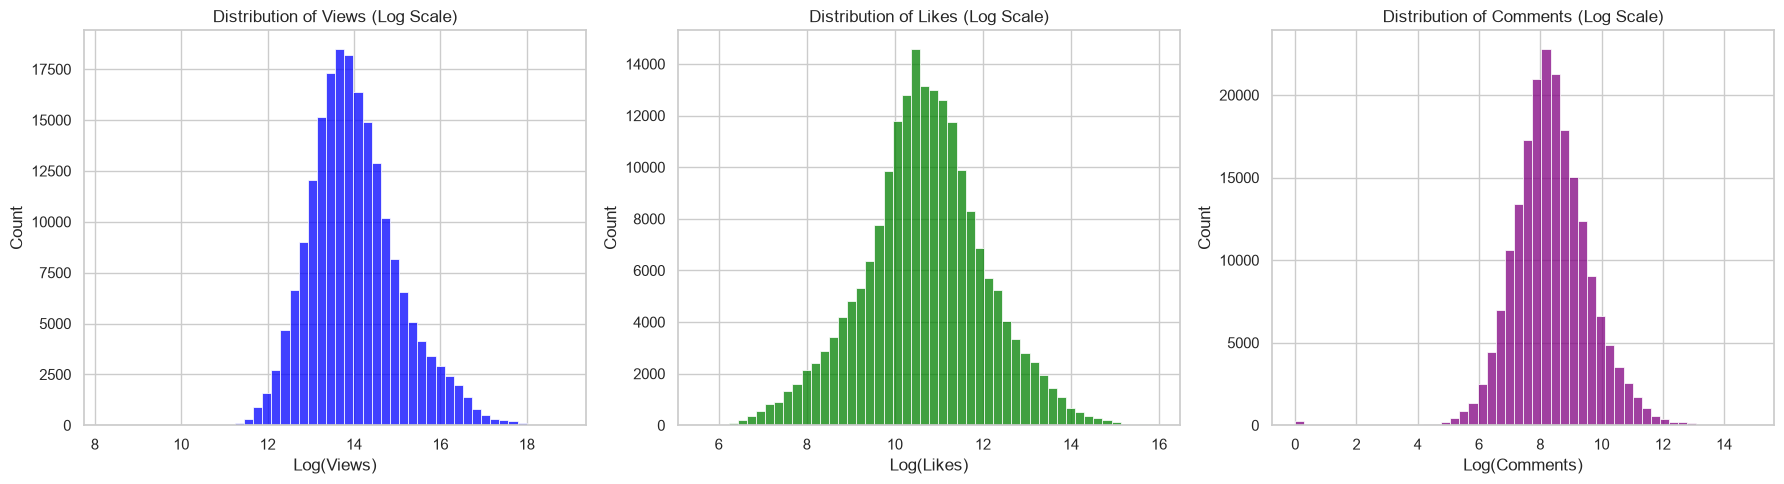

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# We use np.log1p (log(1+x)) to avoid errors with zero values
sns.histplot(np.log1p(df['views']), bins=50, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Views (Log Scale)')
axes[0].set_xlabel('Log(Views)')

sns.histplot(np.log1p(df['likes']), bins=50, ax=axes[1], color='green')
axes[1].set_title('Distribution of Likes (Log Scale)')
axes[1].set_xlabel('Log(Likes)')

sns.histplot(np.log1p(df['comments']), bins=50, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Comments (Log Scale)')
axes[2].set_xlabel('Log(Comments)')

plt.tight_layout()
plt.show()

## Correlation Heatmap
Do views guarantee likes? Do likes guarantee comments? We will use a correlation matrix to see how strongly these metrics move together. A value close to 1 means a perfect positive correlation.

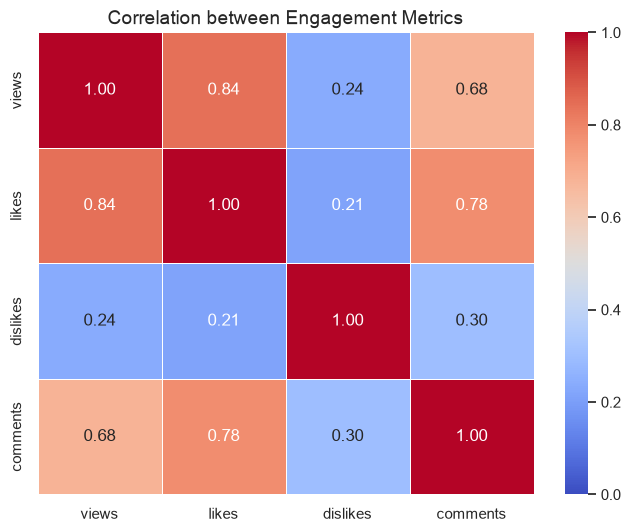

In [14]:
# Select only the engagement metrics
engagement_cols = ['views', 'likes', 'dislikes', 'comments']
corr_matrix = df[engagement_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation between Engagement Metrics', fontsize=14)
plt.show()

## Audience Sentiment Analysis
To understand audience sentiment, raw likes aren't enough. We need to look at the **Like Ratio** (Likes divided by total interactions). 
*Formula: `likes / (likes + dislikes)`*

The median like ratio is: 0.976


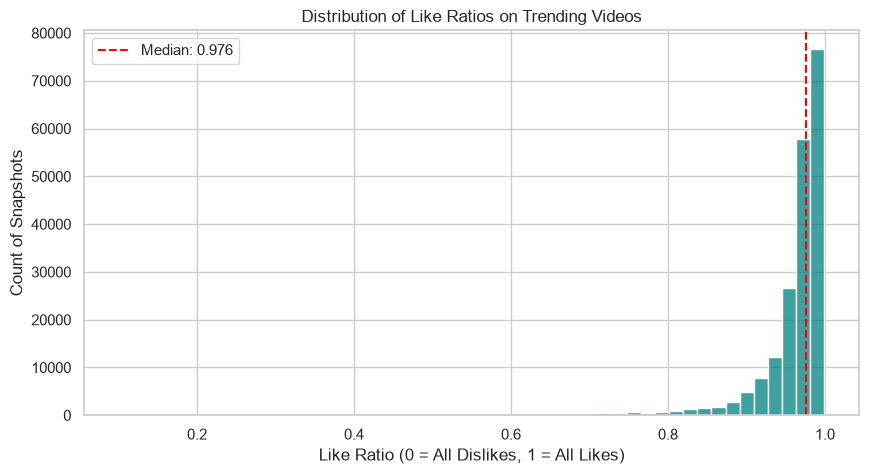

In [15]:
# Calculate the Like Ratio
# We add a small number (1e-5) to the denominator to prevent division by zero errors
df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes'] + 1e-5)

# Calculate the median as stated in our findings
median_ratio = df['like_ratio'].median()
print(f"The median like ratio is: {median_ratio:.3f}")

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['like_ratio'], bins=50, color='teal')
plt.axvline(median_ratio, color='red', linestyle='--', label=f'Median: {median_ratio:.3f}')
plt.title('Distribution of Like Ratios on Trending Videos')
plt.xlabel('Like Ratio (0 = All Dislikes, 1 = All Likes)')
plt.ylabel('Count of Snapshots')
plt.legend()
plt.show()

# 03. Time-Series Analysis

## Tracking View Growth Over Time
Because our dataset contains daily snapshots of the same videos, we can track their lifecycle on the trending page. Let's find the top 5 most viewed videos in our dataset and plot their growth trajectories over time to see how quickly they accumulate views.

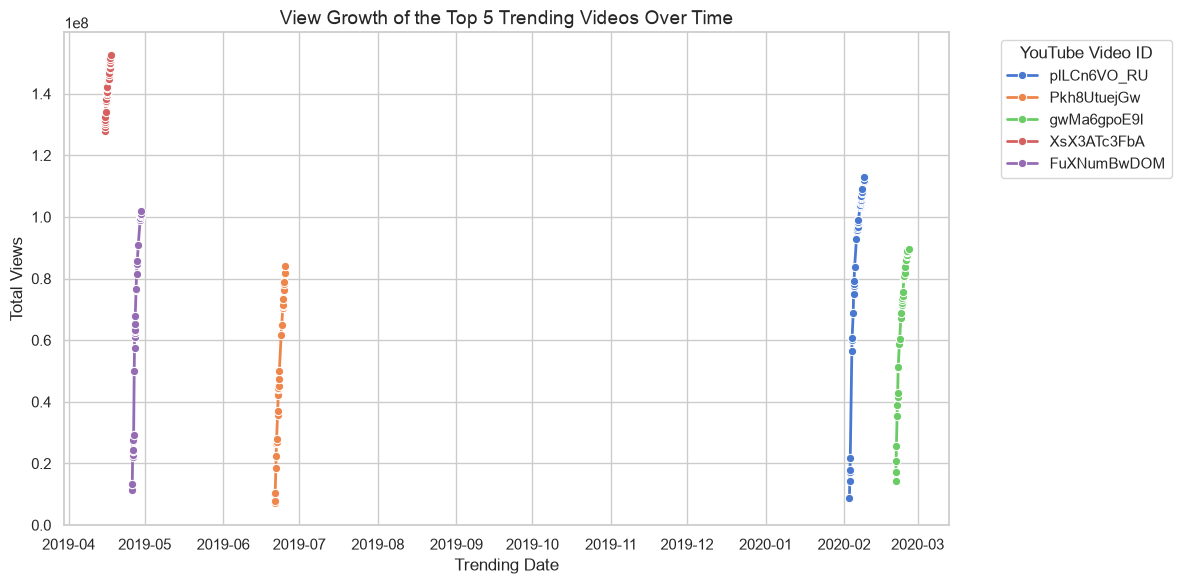

In [16]:
# 1. Identify the top 5 videos with the highest maximum views
top_videos = df.groupby('ytvideoid')['views'].max().nlargest(5).index

# 2. Filter our original dataset to ONLY include these 5 specific videos
top_vids_df = df[df['ytvideoid'].isin(top_videos)]

# 3. Plot the time-series data
plt.figure(figsize=(12, 6))

# sns.lineplot automatically connects the chronological snapshots for each video
sns.lineplot(
    data=top_vids_df, 
    x='timestamp', 
    y='views', 
    hue='ytvideoid', 
    marker='o', 
    linewidth=2
)

# Formatting the chart
plt.title('View Growth of the Top 5 Trending Videos Over Time', fontsize=14)
plt.xlabel('Trending Date')
plt.ylabel('Total Views')

# Move the legend outside the chart so it doesn't block the lines
plt.legend(title='YouTube Video ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 04. Conclusion & Key Takeaways

This exploratory data analysis of over 200,000 YouTube trending snapshots reveals several core truths about viral video performance:

*   **Engagement is intrinsically linked:** The strong positive correlation (0.84) between views and likes proves that reach and active engagement scale together. High views are rarely empty; they reliably drive active audience participation.
*   **The Trending Tab is a positive space:** With a median like ratio of 0.97, videos that reach the trending page are almost universally well-received by their audience. Heavily disliked or deeply polarizing content rarely survives the algorithm's initial push.
*   **Viral trajectories vary:** As seen in our time-series analysis, there is no single path to trending. Some content achieves massive, immediate velocity on day one, while other videos build momentum steadily over several days.

### Final Thought
Understanding these metrics provides a clear blueprint for algorithmic success. To land on the trending page, content must not only attract initial clicks but also foster an overwhelmingly positive, highly engaged audience reaction.